## Change of mind triggered SSM

In [ ]:
%reload_ext autoreload
%autoreload 2

In [152]:
import os
import pickle
import numpy as np
import pandas as pd
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
from scipy.special import comb
from dynamax.hidden_markov_model import CategoricalHMM
from spyglass.shijiegu.changeOfMind import color_by_rat
from spyglass.shijiegu.changeOfMind_statespace import (cycle4_1, cycle4_2, cycle4_3, cycle4_4, cycle4_5, cycle4_6,
                                                       cycle3_1, cycle3_2, cycle3_3, cycle3_4, cycle3_5, cycle3_6, cycle3_7, cycle3_8, cycle_lengths)
from spyglass.shijiegu.changeOfMind_statespace import (construct_transition_matrix, construct_emission_matrix,
                                                      initialize_state_space, em_state_space, get_day_observations,
                                                      return_cycle_type_posterior, return_target_seq_posterior,
                                                      return_A_seq_level,
                                                      return_triggered_matrix,
                                                      get_trained_model, return_triggered_day)

from jax import vmap
from functools import partial

from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from spyglass.shijiegu.decodeHelpers import runSessionNames
from spyglass.shijiegu.Analysis_SGU import ChangeofMindTheta, ChangeofMindRemoteTheta
import optax

[13:54:57][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[13:54:57][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[13:54:57][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[13:54:57][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[13:54:57][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.


In [63]:
list_of_days_animals, learning_flag, encoding_set_animals, classifier_param_name_animals, seq_animals = {}, {}, {}, {}, {}

animal = "molly"
list_of_days_animals[animal]  = ['20220416','20220417','20220418','20220419','20220420']
learning_flag[animal] = [1,1,1,1,0] #denote for each day, if it is a learning day
encoding_set_animals[animal]  = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'
seq_animals[animal] = 'seq2'

animal = "lewis"
list_of_days_animals[animal] = ['20240105','20240106','20240107','20240108','20240109','20240110','20240113']
learning_flag[animal] = [1,1,1,1,1,0,0] #denote for each day, if it is a learning day

encoding_set_animals[animal] = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'
seq_animals[animal] = 'rev2'

In [64]:
animal = "eliot"
list_of_days_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']
#list_of_days_animals[animal] = ['20221020','20221021','20221022','20221023']
learning_flag[animal] = [1,1,1,1,1,1,0,0,0] #denote for each day, if it is a learning day
encoding_set_animals[animal] = '2Dheadspeed_above_4_andlowmua'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'
seq_animals[animal] = 'seq2'

animal = 'julio'
#list_of_days_animals[animal] = ['20230808','20230809','20230810','20230811']
list_of_days_animals[animal] = ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']
learning_flag[animal] = [1 for d in ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806']] #denote for each day, if it is a learning day
learning_flag[animal] += [0 for d in ['20230807','20230808','20230809','20230810','20230811']]

encoding_set_animals[animal] = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'
seq_animals[animal] = 'seq2'

animal = 'klein'
list_of_days_animals[animal]  = ['20231101','20231102','20231103','20231104','20231105',#
                 '20231106','20231107','20231108','20231109','20231111']
learning_flag[animal] = [1 for d in ['20231101','20231102','20231103','20231104','20231105',#
                 '20231106','20231107']]
learning_flag[animal] += [0 for d in ['20231108','20231109','20231111']]

encoding_set_animals[animal] = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'
seq_animals[animal] = 'rev2'

### Run models

In [115]:
output_folder = '/stelmo/shijie/change_of_mind_analysis/figure_ssm/'

for animal in ["eliot","lewis","klein","julio","molly"]:
    seq = seq_animals[animal] 
    com_triggers_animal = []
    notcom_triggers_animal = []
    for day_ind in range(len(list_of_days_animals[animal])):
    
        day = list_of_days_animals[animal][day_ind]
        if not learning_flag[animal][day_ind]:
            continue
        parameters = {"p_stay_in_seq": 0.8,
                          "p_jump_to_other_seq": 0.2, # proportional to 4B * 5
                          "p_jump_to_other_seq_type": 0.1, # proportional to 3b * 8
                          "p_jump_to_random": 0.5, "noise_level": 1}
        
        com_triggers_day, notcom_triggers_day = return_triggered_day(animal, day, seq, init_num = 2, **parameters)
        com_triggers_animal.append(com_triggers_day - np.nanmean(notcom_triggers_day, axis = 0))
        notcom_triggers_animal.append(notcom_triggers_day)
    
    com_triggers_animal = np.vstack(com_triggers_animal)
    notcom_triggers_animal = np.vstack(notcom_triggers_animal)
    
    output_path = os.path.join(output_folder,f"{animal}_ssm_triggers_learning.pickle")
    data = {"com_triggers_animal": com_triggers_animal,
            "notcom_triggers_animal": notcom_triggers_animal}
    
    with open(output_path, 'wb') as file:
        pickle.dump(data, file, protocol=pickle.HIGHEST_PROTOCOL)
        print(f"Data successfully pickled and saved.")

eliot20221018_.nwb


em log  6908.2637
found a better solution


em log  6886.1875
eliot20221019_.nwb


em log  6818.285
found a better solution


em log  6818.2847
eliot20221020_.nwb


...

em log  6873.776
found a better solution
molly20220418_.nwb


em log  6833.8486
found a better solution


em log  6828.9834
molly20220419_.nwb


em log  6811.0425
found a better solution


em log  6806.7026
Data successfully pickled and saved.


Data successfully loaded.
Data successfully loaded.
Data successfully loaded.
Data successfully loaded.
Data successfully loaded.


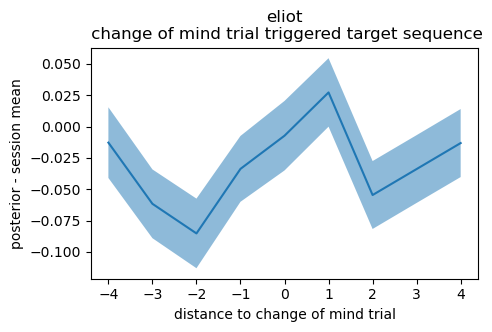

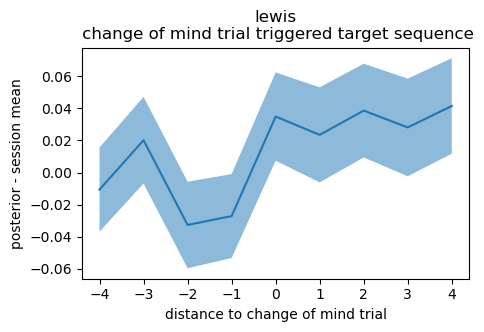

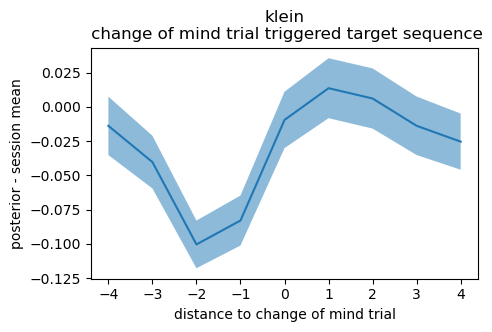

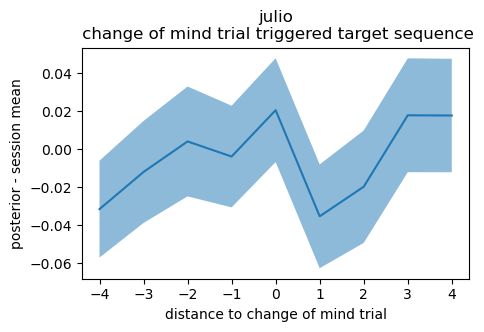

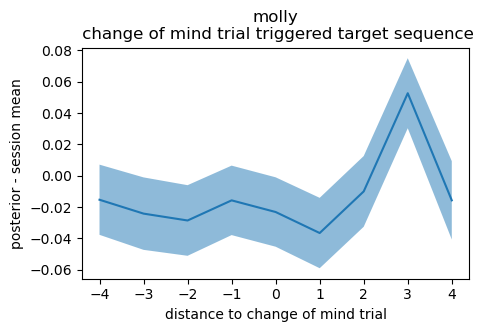

In [124]:
for animal in ["eliot","lewis","klein","julio","molly"]:
    output_path = os.path.join(output_folder,f"{animal}_ssm_triggers_learning.pickle")
    
    with open(output_path, 'rb') as file:
        loaded_data = pickle.load(file)
        print(f"Data successfully loaded.")

    com_triggers_animal = loaded_data["com_triggers_animal"]
    notcom_triggers_animal = loaded_data["notcom_triggers_animal"]
        
    t_minus = 4
    fig, axes = plt.subplots(1, 1, figsize=(5, 3))
    
    data1 = com_triggers_animal
    
    mean = np.nanmean(data1, axis = 0)
    sd_err = np.nanstd(data1, axis = 0)/np.sqrt(np.shape(data1)[0])
    
    x = np.arange(len(mean))- t_minus
    axes.plot(x, mean)
    axes.fill_between(x, mean - sd_err, mean + sd_err, alpha = 0.5)
    axes.set_ylabel("posterior - session mean")
    axes.set_xlabel("distance to change of mind trial")
    axes.set_title(f"{animal}\n change of mind trial triggered target sequence")
    
    # data1 = notcom_triggers_animal
    # mean = np.nanmean(data1, axis = 0)
    # sd_err = np.nanstd(data1, axis = 0)/np.sqrt(np.shape(data1)[0])
    
    # x = np.arange(len(mean))- t_minus
    # axes.plot(x, mean)
    # axes.fill_between(x, mean - sd_err, mean + sd_err, alpha = 0.5)

Data successfully loaded.
Rat eliot has 176 these data points.
Data successfully loaded.
Rat lewis has 126 these data points.
Data successfully loaded.
Rat klein has 211 these data points.
Data successfully loaded.
Rat julio has 92 these data points.
Data successfully loaded.
Rat molly has 84 these data points.


[Text(0, 0, 'Rat E'),
 Text(1, 0, 'Rat L'),
 Text(2, 0, 'Rat K'),
 Text(3, 0, 'Rat J'),
 Text(4, 0, 'Rat M')]

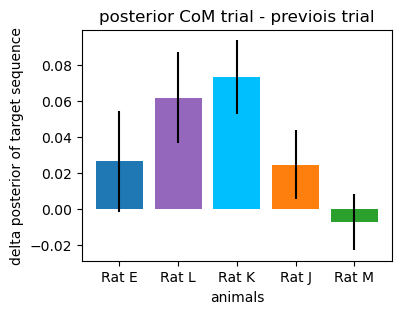

In [153]:
fig, axes = plt.subplots(1, 1, figsize=(4, 3))

animal_ind = 0
animals = ["eliot","lewis","klein","julio","molly"]
for animal in animals:
    #output_path = os.path.join(output_folder,f"{animal}_ssm_triggers.pickle")
    output_path = os.path.join(output_folder,f"{animal}_ssm_triggers_learning.pickle")
    
    with open(output_path, 'rb') as file:
        loaded_data = pickle.load(file)
        print(f"Data successfully loaded.")

    com_triggers_animal = loaded_data["com_triggers_animal"]
    notcom_triggers_animal = loaded_data["notcom_triggers_animal"]
        
    t_minus = 4
    ind_com = int((com_triggers_animal.shape[1] + 1) / 2) - 1
    ind_com_minus1 = ind_com - 1
    ind_com_plus1 = ind_com + 1
    
    data1 = com_triggers_animal[:,ind_com] - com_triggers_animal[:,ind_com_minus1]
    mean = np.nanmean(data1)
    sd_err = np.nanstd(data1)/np.sqrt(len(data1))
    
    axes.bar(animal_ind, mean, yerr = sd_err, color = color_by_rat[animal])
    print(f"Rat {animal} has {len(data1)} these data points.")

    animal_ind += 1

axes.set_title("posterior CoM trial - previois trial")
axes.set_ylabel("delta posterior of target sequence")
axes.set_xlabel("animals")
axes.set_xticks(np.arange(len(animals)))
axes.set_xticklabels(["Rat " + animal[0].upper() for animal in animals])

In [148]:
GLM_xy = []

animal_ind = 0
animals = ["eliot","lewis","klein","julio","molly"]
for animal in animals:
    #output_path = os.path.join(output_folder,f"{animal}_ssm_triggers.pickle")
    output_path = os.path.join(output_folder,f"{animal}_ssm_triggers_learning.pickle")
    
    with open(output_path, 'rb') as file:
        loaded_data = pickle.load(file)
        print(f"Data successfully loaded.")

    com_triggers_animal = loaded_data["com_triggers_animal"]
    notcom_triggers_animal = loaded_data["notcom_triggers_animal"]
        
    t_minus = 4
    ind_com = int((com_triggers_animal.shape[1] + 1) / 2) - 1
    ind_com_minus1 = ind_com - 1
    ind_com_plus1 = ind_com + 1
    
    data1 = com_triggers_animal[:,ind_com]
    data2 = com_triggers_animal[:,ind_com_minus1]
    animal_category = [a == animal for a in animals]
    for ind in range(len(data1)):
        GLM_xy.append(animal_category + [
            1,
            data1[ind] - data2[ind]
        ])
                    

Data successfully loaded.
Data successfully loaded.
Data successfully loaded.
Data successfully loaded.
Data successfully loaded.


In [149]:
GLM_xy = np.array(GLM_xy)
GLM_xy[0]

array([ 1.       ,  0.       ,  0.       ,  0.       ,  0.       ,
        1.       , -0.0078592])

In [150]:
from scipy.stats import ranksums
from scipy.stats import fisher_exact
import starbars
import statsmodels.api as sm

In [151]:
## Model 1: no theta or with theta
feature_dict = {f"Rat {animals[animal_ind][0].upper()}":GLM_xy[:,animal_ind] for animal_ind in range(len(animals))}
feature_dict["com"] = GLM_xy[:,len(animals)]
#feature_dict["com minus 1"] = GLM_xy[:,(len(animals)+1)]

X = pd.DataFrame(feature_dict)
X = sm.add_constant(X)
y = GLM_xy[:,-1]

"""a) Mixed Linear Effect"""
ols_model = sm.OLS(y,X)
ols_result1 = ols_model.fit()

print("Mixed Linear Effect \n",ols_result1.summary())


Mixed Linear Effect 
                             OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     1.557
Date:                Wed, 05 Nov 2025   Prob (F-statistic):              0.184
Time:                        23:27:10   Log-Likelihood:                -129.48
No. Observations:                 689   AIC:                             269.0
Df Residuals:                     684   BIC:                             291.6
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Rat E         -0.0034      0.0

Data successfully loaded.
Data successfully loaded.
Data successfully loaded.
Data successfully loaded.
Data successfully loaded.


[Text(0, 0, 'Rat E'),
 Text(1, 0, 'Rat L'),
 Text(2, 0, 'Rat K'),
 Text(3, 0, 'Rat J'),
 Text(4, 0, 'Rat M')]

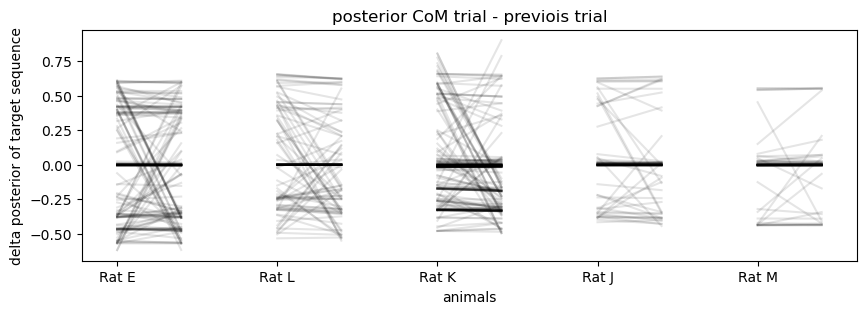

In [120]:
fig, axes = plt.subplots(1, 1, figsize=(10, 3))

animal_ind = 0
animals = ["eliot","lewis","klein","julio","molly"]
for animal in animals:
    output_path = os.path.join(output_folder,f"{animal}_ssm_triggers_learning.pickle")
    
    with open(output_path, 'rb') as file:
        loaded_data = pickle.load(file)
        print(f"Data successfully loaded.")

    com_triggers_animal = loaded_data["com_triggers_animal"]
    notcom_triggers_animal = loaded_data["notcom_triggers_animal"]
        
    t_minus = 4
    ind_com = int((com_triggers_animal.shape[1] + 1) / 2) - 1
    ind_com_minus1 = ind_com - 1
    ind_com_plus1 = ind_com + 1
    
    data1 = com_triggers_animal[:,ind_com]
    data2 = com_triggers_animal[:,ind_com_minus1]

    for data_ind in range(len(data1)):
        axes.plot([animal_ind, animal_ind + 0.4], [data1[data_ind], data2[data_ind]], color = 'k', alpha = 0.1)

    animal_ind += 1

#axes.set_ylim([-0.1, 0.1])
axes.set_title("posterior CoM trial - previois trial")
axes.set_ylabel("delta posterior of target sequence")
axes.set_xlabel("animals")
axes.set_xticks(np.arange(len(animals)))
axes.set_xticklabels(["Rat " + animal[0].upper() for animal in animals])

In [92]:
ind_com_minus1

4

In [ ]:
animal = "eliot"
seq = seq_animals[animal] 
com_triggers_animal = []
notcom_triggers_animal = []
for day_ind in range(len(list_of_days_animals[animal])):

    day = list_of_days_animals[animal][day_ind]
    if not learning_flag[animal][day_ind]:
        continue
    com_triggers_day, notcom_triggers_day = return_triggered_day(animal, day, seq, init_num = 1)
    com_triggers_animal.append(com_triggers_day - np.nanmean(notcom_triggers_day, axis = 0))
    notcom_triggers_animal.append(notcom_triggers_day)

com_triggers_animal = np.vstack(com_triggers_animal)
notcom_triggers_animal = np.vstack(notcom_triggers_animal)

In [ ]:
animal = "eliot"
day = "20221021"
seq = seq_animals[animal]
emission_all, df_all, hmm, em_params, input_params = get_trained_model(animal, day, init_num = 1)

min_num = 0
max_num = 80
t_minus = 4
t_plus = 4
# input

com_triggers_all = []
notcom_triggers_all = []
for session_ind in range(len(emission_all)):

    df = df_all[session_ind]
    all_outers = np.array(df.OuterWellIndex)-1
    all_outers = jnp.array(all_outers[min_num:max_num])
    if (all_outers == np.nan).any():
        print("nan encountered in outer well visits, skipping this session.")
        continue
    
    target_posterior, confound1_posterior, confound2_posterior = return_target_seq_posterior(hmm, em_params, all_outers, seq)

    # do triggering

    subset_df = df.loc[min_num:max_num]
    subset_df_com = subset_df[subset_df.change_of_mind]
    subset_df_notcom = subset_df[~subset_df.change_of_mind]
    
    com_trialID = np.array(subset_df_com.index)
    notcom_trialID = np.array(subset_df_notcom.index)
    

    com_triggers = return_triggered_matrix(com_trialID, target_posterior, t_minus = t_minus, t_plus = t_plus)
    notcom_triggers = return_triggered_matrix(notcom_trialID, target_posterior, t_minus = t_minus, t_plus = t_plus)
    com_triggers_all.append(com_triggers)
    notcom_triggers_all.append(notcom_triggers)

com_triggers_day = np.vstack(com_triggers_all)
notcom_triggers_day = np.vstack(notcom_triggers_all)

In [ ]:
com_triggers_day = np.vstack(com_triggers_all)
notcom_triggers_day = np.vstack(notcom_triggers_all)

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(5, 3))

data1 = com_triggers_day

mean = np.nanmean(data1, axis = 0)
sd_err = np.nanstd(data1, axis = 0)/np.sqrt(np.shape(data1)[0])

x = np.arange(len(mean))- t_minus
axes.plot(x, mean)
axes.fill_between(x, mean - sd_err, mean + sd_err, alpha = 0.5)

data1 = notcom_triggers_day
mean = np.nanmean(data1, axis = 0)
sd_err = np.nanstd(data1, axis = 0)/np.sqrt(np.shape(data1)[0])

x = np.arange(len(mean))- t_minus
axes.plot(x, mean)
axes.fill_between(x, mean - sd_err, mean + sd_err, alpha = 0.5)